<h1 style="text-align:center; color:green; font-size:48px;">
OEMOF TUTORIAL
</h1>

### Support functions

In [15]:
import pandas as pd

# Path to your detailed results file
csv_path = r"C:\Users\PC\Documents\KTH Master 2\Practical Optimization of Energy Networks\Network_optmisation\Project__DH\Outputs\optimization_results.csv"

# Load the CSV
df = pd.read_csv(csv_path)

# Inspect column names to confirm
print(df.columns)

# Sum the losses column
total_losses = df['losses'].sum()

print(f"Raw total losses (unit as in file): {total_losses}")

# --- UNIT CONVERSION ---
# You need to know what unit 'losses' is stored in. Common cases:
# 1) If 'losses' is power in kW at each time step:
#        multiply by time step duration (hours) to get kWh.
# 2) If 'losses' is already energy in kWh per row, you can sum directly.

# Example: assume 'losses' is power in kW, and your time step is 1 hour.
time_step_hours = 1.0  # change if different, e.g., 0.25 for 15-min steps

total_kwh = total_losses * time_step_hours
total_mwh = total_kwh / 1000.0

print(f"Total losses: {total_kwh:,.1f} kWh  ({total_mwh:,.3f} MWh)")

# Optionally save these totals to a new CSV or append to a summary file
summary = pd.DataFrame({
    "metric": ["total_losses_kWh", "total_losses_MWh"],
    "value": [total_kwh, total_mwh]
})

summary.to_csv(r"C:\Users\PC\Documents\KTH Master 2\Practical Optimization of Energy Networks\Network_optmisation\Project__DH\Outputs\losses_summary.csv",
               index=False)
print("Saved summary to losses_summary.csv")


Index(['id', 'from_node', 'to_node', 'length', 'hp_type', 'capacity',
       'direction', 'costs', 'losses'],
      dtype='object')
Raw total losses (unit as in file): 66.08409415581599
Total losses: 66.1 kWh  (0.066 MWh)
Saved summary to losses_summary.csv


In [16]:
# Levelized Cost of Heat

def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)

    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )
    
# Equivalent Periodic Cost

def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)

    return invest_cost * af

In [17]:
"""!pip install numpy==2.0.2 pandas==2.3.1
!pip install matplotlib 
!pip install osmnx>=2.0 oemof.solph==0.5.6"""

'!pip install numpy==2.0.2 pandas==2.3.1\n!pip install matplotlib \n!pip install osmnx>=2.0 oemof.solph==0.5.6'

# Import libraries

In [18]:
import os
import warnings
import logging
import pandas as pd
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)  
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph

# Example

<img src="Example_OEMOF.png" width="40%">

## 1.1 Create the energy system

In [19]:
from oemof.solph import NonConvex

# read the input data file
filename = r"OEMOF_files/Step4.csv"
data = pd.read_csv(filename, delimiter=";")


# specifying the solver
solver = "glpk"
solver_verbose = False

# Create energy system
datetimeindex = create_time_index(2022, number=len(data)) # By default, the function creates an hourly index for one year.
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

# Add components to the energy system
# Buses
electrical_bus = Bus(label="electrical_bus") # Electricity bus
thermal_bus = Bus(label="thermal_bus") # Heat bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biogas_bus = Bus(label="biogas_bus") # Natural gas bus

energysystem.add(electrical_bus, thermal_bus, gas_bus, biogas_bus)




# Excess electricity sink
energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus: Flow(variable_costs=data["electricity_price"] * -1)}
    )
)

# Gas source with cost from gas + CO2
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow(variable_costs=data["gas_price"] + data["co2_price"] * 0.2008)})
                )



# Gas source with cost biogas
energysystem.add(
    Source(label="bio_gas",outputs={biogas_bus: Flow(variable_costs=60.0)})
                )

# Grid electricity source with cost electricity + CO2
energysystem.add(
    Source(label="electricity_grid",outputs={electrical_bus: Flow(variable_costs=data["electricity_price"] + data["co2_price"] * 0.026)})
                )

# Thermal demand sink
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value=4.91653062658096,
            fix=data["thermal_demand"]  #/max(data["thermal_demand"])
        )},
    )
)


# natural gas CHP
energysystem.add(
    Converter(
        label="chp_gas",
        inputs={gas_bus: Flow()},
        outputs={
            electrical_bus: Flow(#min=0.1,
                                 #min=0.4,
                                #nominal_value=0.75,
                                #nonconvex=NonConvex(
                                #minimum_uptime=3, # once started, stay ON ≥ 3 time steps
                                #minimum_downtime=3, # once stopped, stay OFF ≥ 3 time steps
                                #initial_status=0, # 0 = OFF at start, 1 = ON
                                #startup_costs=300, # cost to switch from OFF → ON
                                #shutdown_costs=10, # cost to switch from ON → OFF
                                #),

                                 
                                 
                                 ),
            thermal_bus: Flow(nominal_value=1.62,
                              min=0.1,
                              variable_costs=0.29)
        },
        conversion_factors={electrical_bus: 0.36, thermal_bus: 0.54}
    )
)

# biomass CHP
energysystem.add(
    Converter(
        label="chp_bio",
        inputs={biogas_bus: Flow()}, # variable cost also has the constant fuel cost
        outputs={
            electrical_bus: Flow(#nominal_value=1.14,
                                 #min=0.1,
                                 #min=0.3,
                                
                                #nonconvex=NonConvex(
                                #minimum_uptime=3, # once started, stay ON ≥ 3 time steps
                                #minimum_downtime=3, # once stopped, stay OFF ≥ 3 time steps
                                #initial_status=0, # 0 = OFF at start, 1 = ON
                                #startup_costs=200, # cost to switch from OFF → ON
                                #shutdown_costs=10, # cost to switch from ON → OFF
                                #),

                                 
                                 ),
            thermal_bus: Flow(nominal_value=1.14, 
                              min=0.1,
                              variable_costs=2.5)
        },
        conversion_factors={electrical_bus: 0.40, thermal_bus: 0.42}
    )
)


# Electric boiler
energysystem.add(
    Converter(
        label="electric_boiler",
        inputs={electrical_bus: Flow(variable_costs =0.5 )},
        outputs={thermal_bus: Flow(nominal_value=2.00, variable_costs=0.5)},
        conversion_factors={thermal_bus: 0.99} 
    )
)


# Heat Pump 11 MW
energysystem.add(
    Converter(
        label="heat_pump_11_MW",
        inputs={electrical_bus: Flow(variable_costs = 1.5)},
        outputs={thermal_bus: Flow(nominal_value=1.1, variable_costs=1.5)},
        conversion_factors={thermal_bus: 3.5} 
    )
)

# Heat Pump 4 MW
energysystem.add(
    Converter(
        label="heat_pump_4_MW",
        inputs={electrical_bus: Flow(variable_costs=1.8 )},
        outputs={thermal_bus: Flow(nominal_value=0.4, variable_costs=1.7)},
        conversion_factors={thermal_bus: 3.5} 
    )
)




Only CO2 price

In [20]:
required = ["electricity_price", "gas_price", "co2_price", "thermal_demand"]

for col in required:
    if col not in data:
        print(f"ERROR: Missing column '{col}'")
    if data[col].isna().any():
        print(f"ERROR: Column '{col}' contains NaN values at rows:", data[col][data[col].isna()])
    print(f"Column '{col}' passed validation.")
    print(len(data[col]), "rows found.")


Column 'electricity_price' passed validation.
8760 rows found.
Column 'gas_price' passed validation.
8760 rows found.
Column 'co2_price' passed validation.
8760 rows found.
Column 'thermal_demand' passed validation.
8760 rows found.


## 1.2 Build and solve model

In [21]:
model = Model(energysystem)


logging.info("Solving the optimization problem.")
model.solve(
    solver='glpk',
    solve_kwargs={"tee": solver_verbose},
    options={"mip_gap": 0.02}   # 2% relative MIP gap
)

'''
This returns a dictionary containing time series and scalar results for all components (buses, converters, sources, etc.).
Or view results for a specific node (for example, a bus).
'''

# Process results
energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

# Save results to file
output_file = os.path.join(os.getcwd(), "Outputs/results.oemof")

energysystem.dump(os.getcwd(), "Outputs/results.oemof")

logging.info("Results have been dumped.")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


## 1.3 Results

In [22]:
energysystem.results

results = energysystem.results["main"]

# get all variables of a specific component/bus
thermal_bus = views.node(results, "thermal_bus")
storage = views.node(results, "storage")




### Analyse thermal node

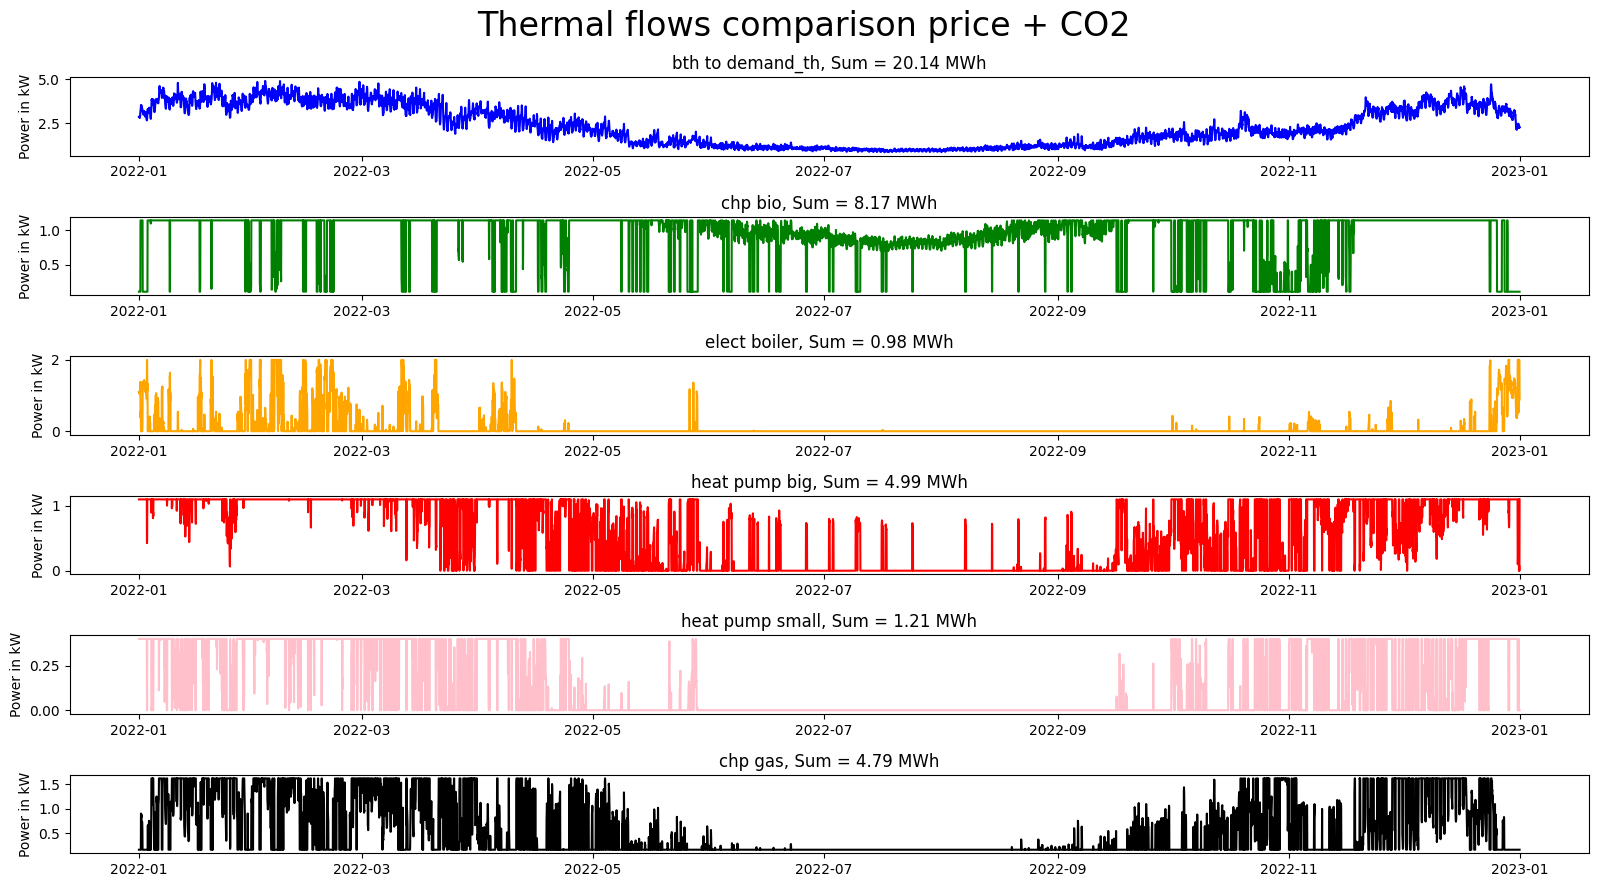

In [23]:
Sum_th_demand = thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')].sum()
Sum_th_prod_chp_gas = thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_chp_bio = thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_boiler = thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_big = thermal_bus["sequences"][(('heat_pump_11_MW', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_small = thermal_bus["sequences"][(('heat_pump_4_MW', 'thermal_bus'), 'flow')].sum()

fig, axs = plt.subplots(6,figsize=(16, 9))
fig.suptitle('Thermal flows comparison price + CO2', fontsize=24)
axs[0].plot(thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')], 'blue')
axs[0].set_title(f'bth to demand_th, Sum = {round(float(Sum_th_demand/1000), 2)} MWh')
axs[1].plot(thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')], 'green')
axs[1].set_title(f'chp bio, Sum = {round(float(Sum_th_prod_chp_bio/1000),2)} MWh')
axs[2].plot(thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')], 'orange')
axs[2].set_title(f'elect boiler, Sum = {round(float(Sum_th_prod_boiler/1000),2)} MWh')
axs[3].plot(thermal_bus["sequences"][(('heat_pump_11_MW', 'thermal_bus'), 'flow')], 'red')
axs[3].set_title(f'heat pump big, Sum = {round(float(Sum_th_prod_hp_big/1000),2)} MWh')
axs[4].plot(thermal_bus["sequences"][(('heat_pump_4_MW', 'thermal_bus'), 'flow')], 'pink')
axs[4].set_title(f'heat pump small, Sum = {round(float(Sum_th_prod_hp_small/1000),2)} MWh')
axs[5].plot(thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')], 'black')
axs[5].set_title(f'chp gas, Sum = {round(float(Sum_th_prod_chp_gas/1000),2)} MWh')

axs[0].set_ylabel('Power in kW')
axs[1].set_ylabel('Power in kW')
axs[2].set_ylabel('Power in kW')
axs[3].set_ylabel('Power in kW')
axs[4].set_ylabel('Power in kW')
axs[5].set_ylabel('Power in kW')


plt.tight_layout()
plt.show()

Only CO2 price 


In [24]:
from oemof.solph import NonConvex

# read the input data file
filename = r"OEMOF_files/Step4.csv"
data = pd.read_csv(filename, delimiter=";")


# specifying the solver
solver = "glpk"
solver_verbose = False

# Create energy system
datetimeindex = create_time_index(2022, number=len(data)) # By default, the function creates an hourly index for one year.
energysystem_CO2_price = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

# Add components to the energy system
# Buses
electrical_bus = Bus(label="electrical_bus") # Electricity bus
thermal_bus = Bus(label="thermal_bus") # Heat bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biogas_bus = Bus(label="biogas_bus") # Natural gas bus

energysystem_CO2_price.add(electrical_bus, thermal_bus, gas_bus, biogas_bus)




# Excess electricity sink
energysystem_CO2_price.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus: Flow(variable_costs=data["electricity_price"] * -1)}
    )
)

# Gas source with cost from gas + CO2
energysystem_CO2_price.add(
    Source(label="natural_gas",outputs={gas_bus: Flow(variable_costs= data["co2_price"] * 0.2008)})
                )



# Gas source with cost biogas
energysystem_CO2_price.add(
    Source(label="bio_gas",outputs={biogas_bus: Flow(variable_costs=0.0)})
                )

# Grid electricity source with CO2 price
energysystem_CO2_price.add(
    Source(label="electricity_grid",outputs={electrical_bus: Flow(variable_costs= data["co2_price"] * 0.026)})
                )

# Thermal demand sink
energysystem_CO2_price.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value=4.91653062658096,
            fix=data["thermal_demand"]  #/max(data["thermal_demand"])
        )},
    )
)


# natural gas CHP
energysystem_CO2_price.add(
    Converter(
        label="chp_gas",
        inputs={gas_bus: Flow()},
        outputs={
            electrical_bus: Flow(#min=0.1,
                                 #min=0.4,
                                #nominal_value=0.75,
                                #nonconvex=NonConvex(
                                #minimum_uptime=3, # once started, stay ON ≥ 3 time steps
                                #minimum_downtime=3, # once stopped, stay OFF ≥ 3 time steps
                                #initial_status=0, # 0 = OFF at start, 1 = ON
                                #startup_costs=300, # cost to switch from OFF → ON
                                #shutdown_costs=10, # cost to switch from ON → OFF
                                #),

                                 
                                 
                                 ),
            thermal_bus: Flow(nominal_value=1.62,
                              min=0.1,
                              variable_costs=0.29)
        },
        conversion_factors={electrical_bus: 0.36, thermal_bus: 0.54}
    )
)

# biomass CHP
energysystem_CO2_price.add(
    Converter(
        label="chp_bio",
        inputs={biogas_bus: Flow()}, # variable cost also has the constant fuel cost
        outputs={
            electrical_bus: Flow(#nominal_value=1.14,
                                 #min=0.1,
                                 #min=0.3,
                                
                                #nonconvex=NonConvex(
                                #minimum_uptime=3, # once started, stay ON ≥ 3 time steps
                                #minimum_downtime=3, # once stopped, stay OFF ≥ 3 time steps
                                #initial_status=0, # 0 = OFF at start, 1 = ON
                                #startup_costs=200, # cost to switch from OFF → ON
                                #shutdown_costs=10, # cost to switch from ON → OFF
                                #),

                                 
                                 ),
            thermal_bus: Flow(nominal_value=1.14, 
                              min=0.1,
                              variable_costs=2.5)
        },
        conversion_factors={electrical_bus: 0.40, thermal_bus: 0.42}
    )
)


# Electric boiler
energysystem_CO2_price.add(
    Converter(
        label="electric_boiler",
        inputs={electrical_bus: Flow(variable_costs =0.5 )},
        outputs={thermal_bus: Flow(nominal_value=2.00, variable_costs=0.5)},
        conversion_factors={thermal_bus: 0.99} 
    )
)


# Heat Pump 11 MW
energysystem_CO2_price.add(
    Converter(
        label="heat_pump_11_MW",
        inputs={electrical_bus: Flow(variable_costs = 1.5)},
        outputs={thermal_bus: Flow(nominal_value=1.1, variable_costs=1.5)},
        conversion_factors={thermal_bus: 3.5} 
    )
)

# Heat Pump 4 MW
energysystem_CO2_price.add(
    Converter(
        label="heat_pump_4_MW",
        inputs={electrical_bus: Flow(variable_costs=1.8 )},
        outputs={thermal_bus: Flow(nominal_value=0.4, variable_costs=1.7)},
        conversion_factors={thermal_bus: 3.5} 
    )
)




In [25]:
required = ["electricity_price", "gas_price", "co2_price", "thermal_demand"]

for col in required:
    if col not in data:
        print(f"ERROR: Missing column '{col}'")
    if data[col].isna().any():
        print(f"ERROR: Column '{col}' contains NaN values at rows:", data[col][data[col].isna()])
    print(f"Column '{col}' passed validation.")
    print(len(data[col]), "rows found.")


Column 'electricity_price' passed validation.
8760 rows found.
Column 'gas_price' passed validation.
8760 rows found.
Column 'co2_price' passed validation.
8760 rows found.
Column 'thermal_demand' passed validation.
8760 rows found.


In [26]:
model_CO2_price = Model(energysystem_CO2_price)


logging.info("Solving the optimization problem.")
model_CO2_price.solve(
    solver='glpk',
    solve_kwargs={"tee": solver_verbose},
    options={"mip_gap": 0.02}   # 2% relative MIP gap
)

'''
This returns a dictionary containing time series and scalar results for all components (buses, converters, sources, etc.).
Or view results for a specific node (for example, a bus).
'''

# Process results
energysystem_CO2_price.results["main"] = processing.results(model_CO2_price)
energysystem_CO2_price.results["meta"] = processing.meta_results(model_CO2_price)

# Save results to file
output_file = os.path.join(os.getcwd(), "Outputs/results_CO2_price.oemof")

energysystem_CO2_price.dump(os.getcwd(), "Outputs/results_CO2_price.oemof")

logging.info("Results have been dumped.")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\oemof\solph\_models.py:263: UserWarning: Optimization ended with status ok and termination condition other
  warnings.warn(
ERROR:pyomo.common.numeric_types:evaluating object as numeric value: flow[electrical_bus,excess_electricity,0]
    (object: <class 'pyomo.core.base.var.VarData'>)
No value for uninitialized VarData object flow[electrical_bus,excess_electricity,0]


ValueError: No value for uninitialized VarData object flow[electrical_bus,excess_electricity,0]

In [ ]:
energysystem_CO2_price.results

results = energysystem_CO2_price.results["main"]

# get all variables of a specific component/bus
thermal_bus = views.node(results, "thermal_bus")
storage = views.node(results, "storage")




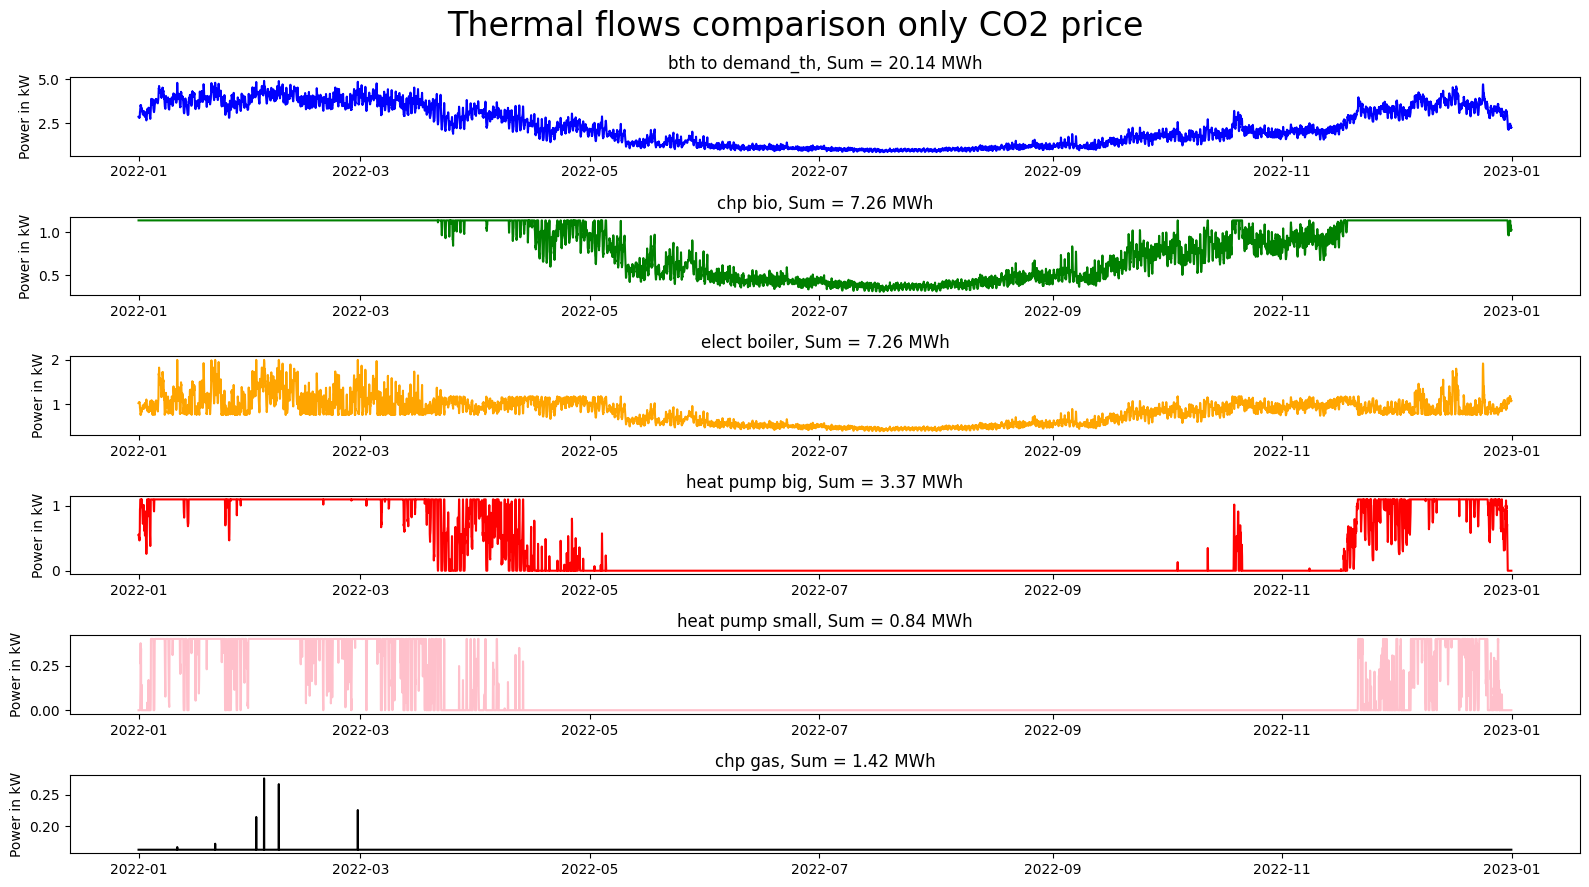

In [ ]:
Sum_th_demand = thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')].sum()
Sum_th_prod_chp_gas = thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_chp_bio = thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_boiler = thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_big = thermal_bus["sequences"][(('heat_pump_11_MW', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_small = thermal_bus["sequences"][(('heat_pump_4_MW', 'thermal_bus'), 'flow')].sum()

fig, axs = plt.subplots(6,figsize=(16, 9))
fig.suptitle('Thermal flows comparison only CO2 price', fontsize=24)
axs[0].plot(thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')], 'blue')
axs[0].set_title(f'bth to demand_th, Sum = {round(float(Sum_th_demand/1000), 2)} MWh')
axs[1].plot(thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')], 'green')
axs[1].set_title(f'chp bio, Sum = {round(float(Sum_th_prod_chp_bio/1000),2)} MWh')
axs[2].plot(thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')], 'orange')
axs[2].set_title(f'elect boiler, Sum = {round(float(Sum_th_prod_boiler/1000),2)} MWh')
axs[3].plot(thermal_bus["sequences"][(('heat_pump_11_MW', 'thermal_bus'), 'flow')], 'red')
axs[3].set_title(f'heat pump big, Sum = {round(float(Sum_th_prod_hp_big/1000),2)} MWh')
axs[4].plot(thermal_bus["sequences"][(('heat_pump_4_MW', 'thermal_bus'), 'flow')], 'pink')
axs[4].set_title(f'heat pump small, Sum = {round(float(Sum_th_prod_hp_small/1000),2)} MWh')
axs[5].plot(thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')], 'black')
axs[5].set_title(f'chp gas, Sum = {round(float(Sum_th_prod_chp_gas/1000),2)} MWh')

axs[0].set_ylabel('Power in kW')
axs[1].set_ylabel('Power in kW')
axs[2].set_ylabel('Power in kW')
axs[3].set_ylabel('Power in kW')
axs[4].set_ylabel('Power in kW')
axs[5].set_ylabel('Power in kW')


plt.tight_layout()
plt.show()